In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, make_circles, load_breast_cancer, load_wine
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
np.set_printoptions(precision=3, suppress=True)


In [2]:
X, y_zero_one = make_blobs(
    n_samples=40,
    centers=[[-2, -2], [2, 2]],
    cluster_std=0.75,
    random_state=7
)

# SVM math is cleaner with labels -1 and +1.
y = np.where(y_zero_one == 0, -1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 rows of X:")
print(X[:5])
print("First 5 labels:", y[:5])


X shape: (40, 2)
y shape: (40,)
First 5 rows of X:
[[-3.548 -2.497]
 [-3.238 -1.598]
 [ 1.775  1.115]
 [ 3.434  2.178]
 [-1.584 -1.907]]
First 5 labels: [-1 -1  1  1 -1]


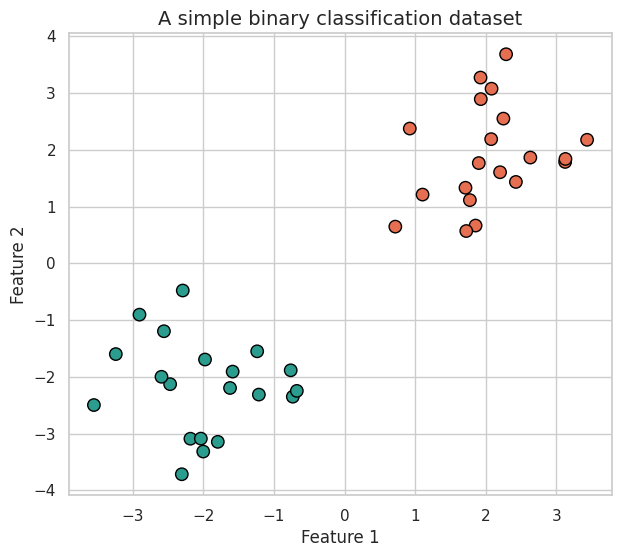

In [3]:
def plot_points(X, y, ax=None, title="Data"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    colors = np.where(y == 1, "#e76f51", "#2a9d8f")
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=80, edgecolor="black")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    return ax

plot_points(X, y, title="A simple binary classification dataset")
plt.show()


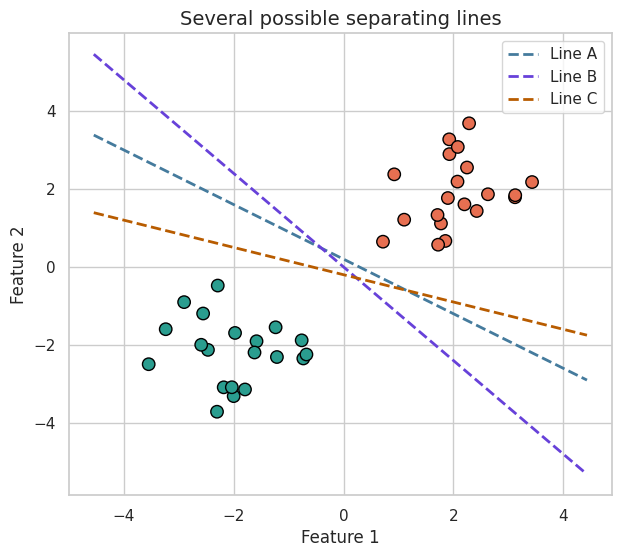

In [6]:
def draw_line(ax, slope, intercept, label=None, color="gray", linestyle="--", linewidth=2):
    x_values = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    y_values = slope * x_values + intercept
    ax.plot(x_values, y_values, color=color, linestyle=linestyle, linewidth=linewidth, label=label)

fig, ax = plt.subplots(figsize=(7, 6))
plot_points(X, y, ax=ax, title="Several possible separating lines")
draw_line(ax, slope=-0.7, intercept=0.2, label="Line A", color="#457b9d")
draw_line(ax, slope=-1.2, intercept=0.0, label="Line B", color="#6741d9")
draw_line(ax, slope=-0.35, intercept=-0.2, label="Line C", color="#b85c00")
ax.legend()
plt.show()


In [10]:
def hinge_loss(X, y, w, b, C=1.0):
    scores = X @ w + b
    margins = y * scores
    losses = np.maximum(0, 1 - margins)
    data_loss = C * np.mean(losses)

    regularization = 0.5 * np.dot(w, w)

    total_loss = data_loss + regularization
    return total_loss, regularization, data_loss, margins, losses

In [11]:
w_demo = np.array([0.0, 0.0])
b_demo = 0.0

loss, reg_loss, data_loss, margins, losses = hinge_loss(X, y, w_demo, b_demo, C=1.0)

print("Initial w:", w_demo)
print("Initial b:", b_demo)
print("Initial total loss:", loss)
print("Initial margin values for first 8 points:", margins[:8])
print("Initial hinge losses for first 8 points:", losses[:8])


Initial w: [0. 0.]
Initial b: 0.0
Initial total loss: 1.0
Initial margin values for first 8 points: [-0. -0.  0.  0. -0. -0.  0. -0.]
Initial hinge losses for first 8 points: [1. 1. 1. 1. 1. 1. 1. 1.]


In [12]:
def svm_gradients(X, y, w, b, C=1.0):
    scores = X @ w + b
    margins = y * scores

    violating = margins < 1

    grad_w = w.copy()
    grad_b = 0.0

    if np.any(violating):
        grad_w += C * np.sum(-y[violating, None] * X[violating], axis=0) / len(y)
        grad_b += C * np.sum(-y[violating]) / len(y)
    return grad_w, grad_b, violating

In [13]:
w_temp = np.array([0.0, 0.0])
b_temp = 0.0
grad_w, grad_b, violating = svm_gradients(X, y, w_temp, b_temp, C=1.0)

print("Gradient for w at initialization:", grad_w)
print("Gradient for b at initialization:", grad_b)
print("Number of margin-violating points:", violating.sum(), "out of", len(X))


Gradient for w at initialization: [-2.023 -2.034]
Gradient for b at initialization: 0.0
Number of margin-violating points: 40 out of 40


In [15]:
def fit_linear_svm_from_scratch(X, y, C=1.0, learning_rate=0.03, n_epochs=800):
    w = np.zeros(X.shape[1])
    b = 0.0
    history = []
    snapshots = {}
    snapshot_epochs = {0, 5, 25, 100, n_epochs - 1}

    for epoch in range(n_epochs):
        # loss computation
        loss, reg_loss, data_loss, margins, losses = hinge_loss(X, y, w, b, C=C)
        # grad calc
        grad_w, grad_b, violating = svm_gradients(X, y, w, b, C=C)

        history.append({
            "epoch": epoch,
            "total_loss": loss,
            "regularization_loss": reg_loss,
            "hinge_loss": data_loss,
            "num_margin_violations": int(violating.sum()),
            "w1": w[0],
            "w2": w[1],
            "b": b
        })

        if epoch in snapshot_epochs:
            snapshots[epoch] = (w.copy(), b)

        # grad descent update
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    snapshots[n_epochs] = (w.copy(), b)
    return w, b, pd.DataFrame(history), snapshots


In [23]:
w_scratch, b_scratch, svm_history, snapshots = fit_linear_svm_from_scratch(
    X, y, C=15.0, learning_rate=0.03, n_epochs=800
)

print("Learned w:", w_scratch)
print("Learned b:", b_scratch)
print("Final loss:", svm_history.iloc[-1]["total_loss"])
print("Final margin violations:", svm_history.iloc[-1]["num_margin_violations"])
svm_history.tail()

Learned w: [0.487 0.5  ]
Learned b: 0.315
Final loss: 0.25896979835700784
Final margin violations: 0.0


,epoch,total_loss,regularization_loss,hinge_loss,num_margin_violations,w1,w2,b
795,795,0.255956,0.234491,0.021466,3,0.467178,0.500726,0.32625
796,796,0.257779,0.257779,0.000000,0,0.495587,0.519568,0.31500
797,797,0.247445,0.242544,0.004901,1,0.480720,0.503981,0.31500
798,798,0.252044,0.235601,0.016443,3,0.474384,0.496148,0.32625
799,799,0.258970,0.258970,0.000000,0,0.502577,0.515127,0.31500


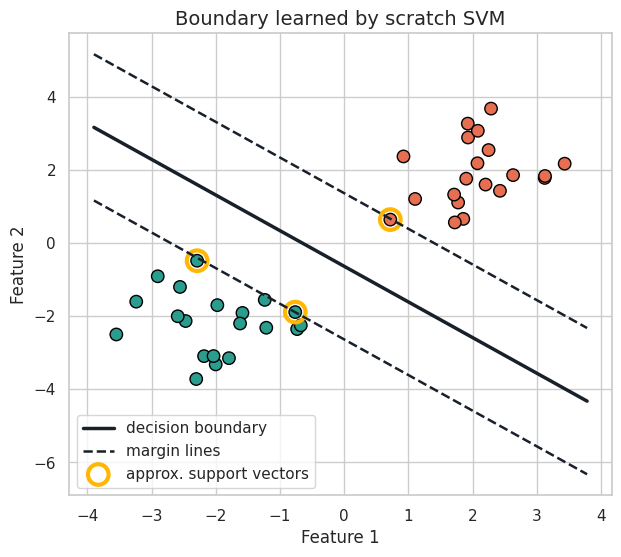

In [24]:
def plot_scratch_svm_boundary(X, y, w, b, title="Scratch linear SVM"):
    fig, ax = plt.subplots(figsize=(7, 6))
    plot_points(X, y, ax=ax, title=title)

    x_min, x_max = ax.get_xlim()
    x_line = np.linspace(x_min, x_max, 200)

    if abs(w[1]) < 1e-12:
        ax.axvline(-b / w[0], color="#18202a", linewidth=2.5, label="decision boundary")
    else:
        y_boundary = -(w[0] * x_line + b) / w[1]
        y_margin_pos = -(w[0] * x_line + b - 1) / w[1]
        y_margin_neg = -(w[0] * x_line + b + 1) / w[1]
        ax.plot(x_line, y_boundary, color="#18202a", linewidth=2.5, label="decision boundary")
        ax.plot(x_line, y_margin_pos, color="#18202a", linestyle="--", linewidth=1.8, label="margin lines")
        ax.plot(x_line, y_margin_neg, color="#18202a", linestyle="--", linewidth=1.8)

    margins = y * (X @ w + b)
    approximate_support = margins <= 1.05
    ax.scatter(
        X[approximate_support, 0],
        X[approximate_support, 1],
        s=220,
        facecolors="none",
        edgecolors="#ffb703",
        linewidths=3,
        label="approx. support vectors"
    )
    ax.legend(loc="best")
    plt.show()

plot_scratch_svm_boundary(X, y, w_scratch, b_scratch, title="Boundary learned by scratch SVM")


In [26]:
linear_svm = SVC(kernel="linear", C=15.0, random_state=7)
linear_svm.fit(X, y)
print("Classes:", linear_svm.classes_)
print("Number of support vectors per class:", linear_svm.n_support_)
print("Support vector indices:", linear_svm.support_)
print("Support vectors shape:", linear_svm.support_vectors_.shape)

Classes: [-1  1]
Number of support vectors per class: [2 1]
Support vector indices: [ 7 32 21]
Support vectors shape: (3, 2)


In [27]:
linear_svm_w = linear_svm.coef_[0]
linear_svm_b = linear_svm.intercept_[0]
print("Learned w:", linear_svm_w)
print("Learned b:", linear_svm_b)

Learned w: [0.473 0.513]
Learned b: 0.3276777826765335


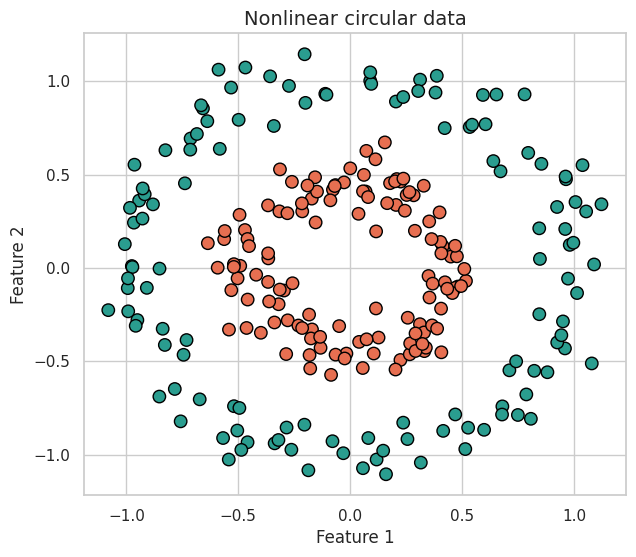

In [29]:
X_circle, y_circle_zero_one = make_circles(n_samples=250, factor=0.45, noise=0.08, random_state=42)
y_circle = np.where(y_circle_zero_one == 0, -1, 1)

plot_points(X_circle, y_circle, title="Nonlinear circular data")
plt.show()


In [31]:
def plot_decision_regions(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.18, levels=[-1, 0, 1], colors=["#2a9d8f", "#e76f51"])
    plot_points(X, y, ax=ax, title=title)

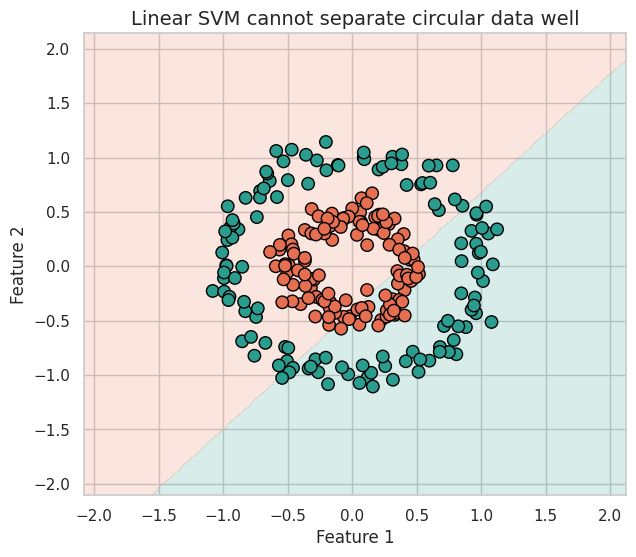

Training accuracy: 0.568


In [33]:
linear_on_circle = SVC(kernel="linear", C=10)
linear_on_circle.fit(X_circle, y_circle)

fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_regions(linear_on_circle, X_circle, y_circle, ax, title="Linear SVM cannot separate circular data well")
plt.show()

print("Training accuracy:", accuracy_score(y_circle, linear_on_circle.predict(X_circle)))


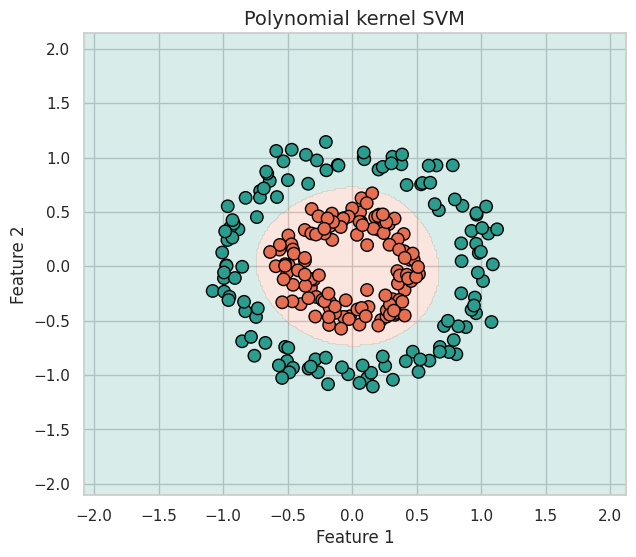

Training accuracy: 1.0


In [35]:
poly_svm = SVC(kernel="rbf", C=1, gamma="scale")
poly_svm.fit(X_circle, y_circle)

fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_regions(poly_svm, X_circle, y_circle, ax, title="Polynomial kernel SVM")
plt.show()

print("Training accuracy:", accuracy_score(y_circle, poly_svm.predict(X_circle)))
